<div style="text-align: left;">
    <img src="../images/Virtuelle_Hochschule_Bayern_logo.svg" alt="ZenBite Picture" style="width: 20%; max-width: 20%; margin-top: 30px; margin-bottom: 20px; float: left;">
    <div style="clear: both;"></div>
</div>

<div class='bar_title'></div>

<span style="color: #E59635; font-size: 56px;">Data-Driven Supply Chain Management</span>

## Session 3b/c - Assignment 

<br>

<span style="color: #7F7F7F;">*Data-Driven Decisions Group (D3)*</span>

## Import Libraries

In [84]:
from dscm.session3 import *

In [85]:
# Just for better display of the graphs

from IPython.display import display, Javascript

disable_autoscroll_js = """
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}
"""

display(Javascript(disable_autoscroll_js))

<IPython.core.display.Javascript object>

In [86]:
# Import pulp and deactivate all logs from pulp
import pulp

pulp.LpSolverDefault.msg = 0

## Part 1: Empirical risk minimization (session 3b)

In the lecture (session 3b) we have learned about the linear regression model and the principle of empirical risk minimization. We implemented the model in Python by using the `ddop` package and incorporated both numerical and categorical features.
In the first part of this assignment you will apply the linear regression model with some other features and compare the results.
You also will practice incorporating seasonal effects in the model.

Import the data for the zenbite restaurant. 

In [87]:
zenbite = load_zenbite()
demand_chicken = zenbite.target['chicken']
features = zenbite.data

In [88]:
train = range(29, 500)
test = range(500, 715)

In [89]:
cu = 15 
co = 5

service_level = cu/(cu+co)
service_level

0.75

## Task 1: The effect of different features

You can see an overview of the features in the data set below.

In [90]:
features

,weekday,month,year,is_holiday,is_closed,weekend,wind,clouds,rain,sunshine,temperature
0,FRI,OCT,2022,0,0,0,1.9,7.7,0.1,150,15.9
1,SAT,OCT,2022,0,0,1,2.7,6.9,10.7,0,13.2
2,SUN,OCT,2022,0,0,1,1.4,8.0,0.4,0,10.6
3,MON,OCT,2022,0,0,0,2.3,6.4,0.0,176,13.3
4,TUE,OCT,2022,0,0,0,1.7,8.0,0.0,0,13.5
...,...,...,...,...,...,...,...,...,...,...,...
710,MON,SEP,2024,0,0,0,3.7,6.4,0.1,208,18.4
711,TUE,SEP,2024,0,0,0,3.1,7.0,0.0,82,17.3
712,WED,SEP,2024,0,0,0,3.0,7.6,0.5,4,18.0
713,THU,SEP,2024,0,0,0,3.2,4.7,3.0,61,14.0


### Question 1.1 
Which features are numerical, binary, and categorical?

Numerical features are features that are continuous and can take any continuous value.
Binary features are features that can take only two values. Categorical features are features that can take a limited (discrete) number of values.


In [91]:
# Type 'numerical' if the feature is numerical, 'categorical' if the feature is categorical and 'binary' if the feature is binary
submit_answer_to_question11({
    "weekday": "categorical",
    "month": "categorical",
    "year": "categorical",
    "is_holiday": "binary",
    "is_closed": "binary",
    "weekend": "binary",
    "wind": "numerical",
    "clouds": "numerical",
    "rain": "numerical",
    "sunshine": "numerical",
    "temperature": "numerical",
})


The answer has been saved locally. Please submit the assignment when you are done with all questions.


## Question 1.2 

Now train a linear regression model with the following features:

- `weekday`
- `month`
- `is_holiday`
- `temperature`

and compare the results with the model from the lecture (session 3b).

First we select the features that should be used in the model.

In [92]:
selected_features = features[['weekday', 'month', 'is_holiday', 'temperature']]

Now we define a function that performs the one-hot encoding for the categorical features.

In [93]:
def one_hot_encode(df, features):
    """
    Perform one-hot encoding on the given list of features in the DataFrame.
    Each feature is encoded with N-1 columns if it has N unique values.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    features (list): List of column names to be one-hot encoded.
    
    Returns:
    pd.DataFrame: The DataFrame with one-hot encoded features.
    """
    df_encoded = df.copy()
    
    for feature in features:
        # Perform one-hot encoding on the feature
        dummies = pd.get_dummies(df_encoded[feature], prefix=feature, drop_first=True)
        
        # Drop the original feature column
        df_encoded = df_encoded.drop(columns=[feature])
        
        # Concatenate the new dummy columns to the DataFrame
        df_encoded = pd.concat([df_encoded, dummies], axis=1)

        # Replace True/False with 1/0
        df_encoded = df_encoded.replace({True: 1, False: 0})
    
    return df_encoded


Use the one-hot encoding function to encode the categorical features.

In [94]:
categorical_feature_names = ['weekday', 'month']

selected_features_encoded = one_hot_encode(selected_features, categorical_feature_names)

Now fit a linear regression model on the data (`selected_features_encoded`)
and compare the results with the model from the lecture that used only the weekday and the temperature as features.
Remember that the model from the lecture had average costs of 60.74.

In [95]:
from ddop2.newsvendor import LinearRegressionNewsvendor
lrnw = LinearRegressionNewsvendor(cu=cu, co=co)
lrnw.fit(selected_features_encoded.iloc[train, :].to_numpy(), demand_chicken.iloc[train])
q_lr_new = lrnw.predict(selected_features_encoded.iloc[test, :].to_numpy())
avg_costs_lr_new = average_costs(demand_chicken.iloc[test], q_lr_new, cu, co)

print(f"The average costs for the new model are: {avg_costs_lr_new:.2f}")
print(f"Cost saving compared to 60.74: {(60.74 - avg_costs_lr_new) / 60.74 * 100:.2f}%")



The average costs for the new model are: 71.44
Cost saving compared to 60.74: -17.62%


Evaluate the model and compare the results with the model with only the weekday and the temperature as features.
When comparing the models, answer the following questions:
1. Which model has a better fit?
    - a) The model from the lecture using only the weekday and the temperature as features
    - b) The model using the weekday, month, is_holiday, and temperature as features
2. How much cost can be saved by using the better model?
    - a) Less than 5%
    - b) Between 5% and 10%
    - c) More than 10%

In [96]:
# Type True if the option is correct and False otherwise
submit_answer_to_question12({
    "Question1": {
        "a": True,
        "b": False,
    },
    "Question2": {
        "a": False,
        "b": False,
        "c": True,
    },
})

The answer has been saved locally. Please submit the assignment when you are done with all questions.


# Interpretation
The lecture model, which used only weekday and temperature as features, achieved average costs of 60.74. In contrast, the new model achieved average costs of 71.44, nearly 17% indicating a worse performance. This demonstrates that adding more features does not necessarily improve a model. The quality and predictive power of a feature are more important than the number of features included. The weekday variable already captures a large part of the weekly demand pattern, while the holiday indicator may provide only limited additional information because holidays occur relatively infrequently. Furthermore, our previous experiments suggested that the month feature can increase overfitting. As a result, the additional features may introduce noise rather than useful information, leading to higher average costs and poorer newsvendor decisions.

## Task 2: Interaction terms

The effect of the weather on the demand can be different in summer compared to winter. To capture this effect, we can include interaction terms between the temperature and the season.

In [97]:
# Add the season to the features
features['season'] = features['month'].apply(lambda x: 'winter' if x in ['DEC', 'JAN', 'FEB'] else 'spring' if x in ['MAR', 'APR', 'MAY'] else 'summer' if x in ['JUN', 'JUL', 'AUG'] else 'fall')

The following plot shows the relationship between the temperature and the demand for the different seasons with a regression line. We can see that the effect of the temperature on the demand is different in summer compared to winter.

In [98]:
# Add an interaction term between the temperature and the one hot encoded season
features['temperature_summer'] = features['temperature'] * (features['season'] == 'summer')
features['temperature_fall'] = features['temperature'] * (features['season'] == 'fall')
features['temperature_winter'] = features['temperature'] * (features['season'] == 'winter')
features['temperature_spring'] = features['temperature'] * (features['season'] == 'spring')


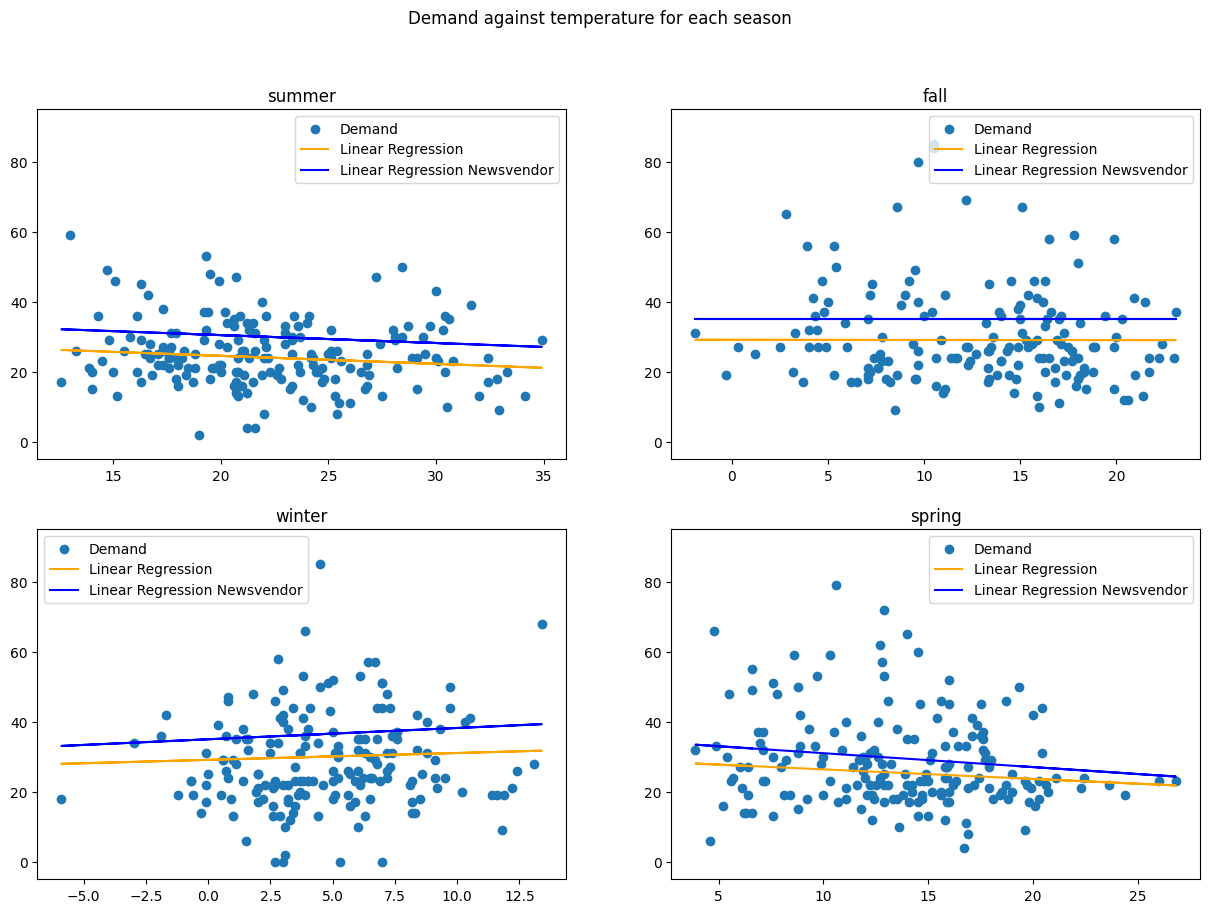

Linear Regression:
Intercept: 29.13
Coefficients:
temperature_summer   -0.23
temperature_fall     -0.00
temperature_winter    0.19
temperature_spring   -0.27


Linear Regression Newsvendor:
Intercept: 35.0
Coefficients:
temperature_summer   -0.23
temperature_fall      0.00
temperature_winter    0.32
temperature_spring   -0.40


In [99]:
seasonal_plot_demand_vs_temperature(features, demand_chicken, train, cu, co)

### Question 2.1 

Calculate the optimal order quantity for the following scenarios:

- A summer day with a temperature of 25 degrees
- A winter day with a temperature of 5 degrees

Also calculate the so called "safety buffer" for each scenario. The safety buffer is the difference between the optimal order quantity 
(prescribed by the linear regression newsvendor model) and the demand forecast (predicted by the linear regression model).
Please round both the optimal order quantity and the safety buffer to the nearest integer.

# Calculation for summer day with a temperature of 25 degrees: 
Linear Regression forecast: 29.13 + (-0.23) x 25 = 23.38

LRNW order quantity: 35 + (-0.23) x 25 = 29.25 

safety buffer = 29-23 = 6


# Calculation for winter day with a temperature of 5 degrees:
Linear Regression forecast: 29.13 + (0.19) x 5 = 30.08

LRNNW order quantity: 35 + (0.32) x 5 = 36.60 

safety buffer: 37-30 = 7


# Interpretation
The LRNW model has a higher intercept because it considers the asymmetric newsvendor costs. Since the underage cost (15) is three times larger than the overage cost (5), stockouts are more expensive than overstocking. As a result, the model intentionally recommends higher order quantities and includes a safety buffer.

In [100]:
# This has to be done by the student
# Submit the correct quantities instead of -1
submit_answer_to_question21({
    "summer_25_degrees":{
        "order_quantity": 29,
        "safety_buffer": 6
    },
    "winter_5_degrees":{
        "order_quantity": 37,
        "safety_buffer": 7
    }
    
})

The answer has been saved locally. Please submit the assignment when you are done with all questions.


### Question 2.2 
Include the interaction terms in the linear regression newsvendor model and compare the results with the model that does not include the interaction terms and only includes the temperature.

We first fit a linear regression model that only includes the temperature.

In [101]:
from ddop2.newsvendor import LinearRegressionNewsvendor
lrn = LinearRegressionNewsvendor(cu=cu, co=co)

In [102]:
# Fit the linear regression newsvendor model
lrn.fit(features[['temperature']].iloc[train], demand_chicken.iloc[train])

q = lrn.predict(features[['temperature']].iloc[test])

# Calculate the cost using the average cost function
average_costs(demand_chicken.iloc[test],q, cu, co)


np.float64(81.690834425)

Now select the features `temperature_summer`, `temperature_fall`, `temperature_winter`, and `temperature_spring` and fit a linear regression model that includes the interaction terms.

In [103]:
interaction_features = features[
    [
        'temperature_summer',
        'temperature_fall',
        'temperature_winter',
        'temperature_spring'
    ]
]

In [104]:
lrn_interaction = LinearRegressionNewsvendor(cu=cu, co=co)
lrn_interaction.fit(interaction_features.iloc[train], demand_chicken.iloc[train])
q_interaction = lrn_interaction.predict(interaction_features.iloc[test])
avg_cost_interaction = average_costs(demand_chicken.iloc[test], q_interaction, cu, co)
print(f"The average costs for the interaction model are: {avg_cost_interaction:.2f}")


The average costs for the interaction model are: 85.85


# Interpretation
Although interaction terms allow the effect of temperature to differ across seasons, they do not improve the model performance in this case. The seasonal temperature effects appear to be relatively weak, while the additional parameters increase model complexity. As the number of parameters increases, the model may fit the training data better but perform worse on unseen test data due to overfitting. Furthermore, the newsvendor model optimizes ordering costs rather than prediction accuracy. Therefore, even if the interaction terms slightly improve the demand forecast, they do not necessarily improve the ordering decisions based on the underage and overage costs. As a result, the interaction model achieves higher average costs on the test set.

Evaluate the model and compare the results with the model without interaction terms.
When comparing the models, answer the following questions:
1. Which model has a better fit?
    - a) The model with interaction terms
    - b) The model without interaction terms
2. How much cost can be saved by using the better model?
    - a) Less than 5%
    - b) Between 5% and 10%
    - c) More than 10%

In [105]:
submit_answer_to_question22({
    "Question1": {
        "a": False,
        "b": True,
    },
    "Question2": {
        "a": True,
        "b": False,
        "c": False,
    },
})

The answer has been saved locally. Please submit the assignment when you are done with all questions.


# 

### Part 2: Time series based prescriptions (session 3c)

In the third part of the session (session 3c) we have learned about the time series based prescriptions. We implemented the model in Python by using the `ddop` package and incorporated so called `lagged features` to capture the effect of the past demand on the current demand / order quantity.
In this smaller part of the assignment we will dealing with lagged features.

For our analysis we will focus on the demand data for the `salmon` dish.

In [106]:
# Therefore we will analyze the demand for salmon
demand_salmon = zenbite.target['salmon']

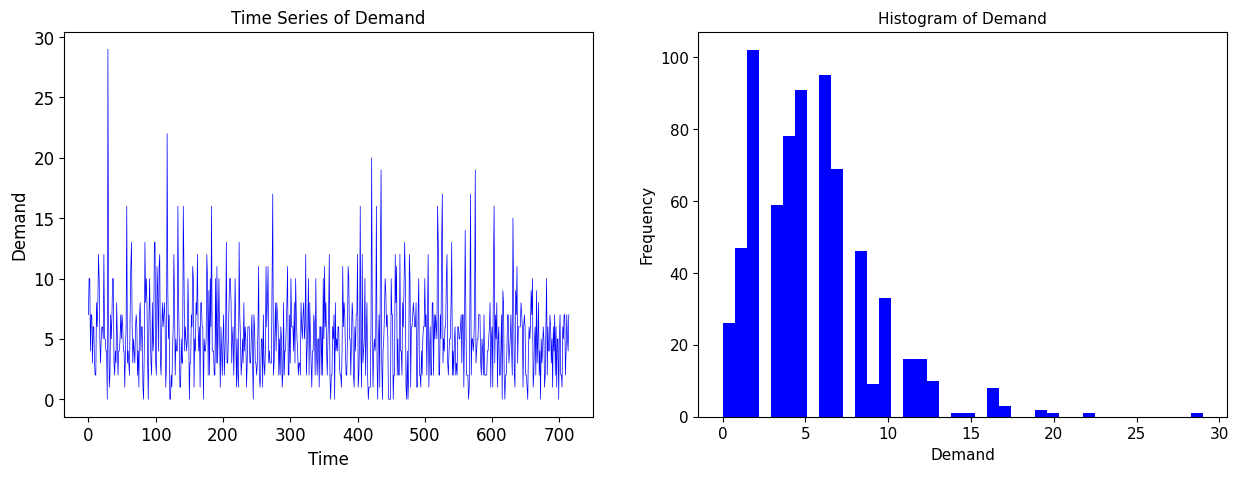

In [107]:
plot_time_series_and_hist(demand_salmon)

### Task 3: Lagged features

Create and analyze an autocorrelation plot for the demand data for the `salmon` dish.
Consider the lag values from 2 to 8 and set $\alpha = 0.01$.

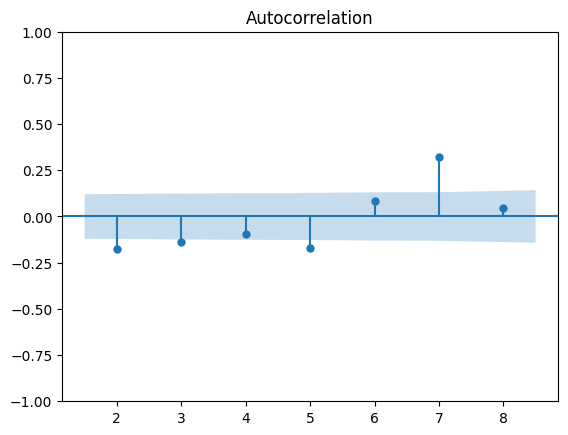

In [108]:
from statsmodels.graphics.tsaplots import plot_acf
fig = plot_acf(demand_salmon[train], lags=range(2,9), zero = False, alpha = 0.01)
plt.title = ("Autocorrelation of the salmon demand")
plt.show()

## Question 3.1 
Which lagged features are significant?

In [109]:
# This has to be done by the student by looking at the plot
# Submit `True` for the lags that are significant and `False` for the lags that are not significant

submit_answer_to_question31({
    "lag2": True,
    "lag3": True,
    "lag4": False,
    "lag5": True,
    "lag6": False,
    "lag7": True,
    "lag8": False,
})

The answer has been saved locally. Please submit the assignment when you are done with all questions.


# Interpretation
The autocorrelation plot indicates significant autocorrelation at lags 2, 3, 5, and 7, as these values lie outside the confidence interval. Among them, lag 7 has the strongest positive autocorrelation, suggesting a weekly demand pattern and making it the most informative lag for predicting future demand.


## Question 3.2
Now include the significant lagged features in the linear regression model and compare the results with the model without lagged features.

As a baseline, we will use a linear regression newsvendor model without lagged features that only includes the `temperature` 
as a feature.
We assume here that the underage and overage costs for the `salmon` dish are 25 and 15 per unit, respectively.

In [110]:
cu_salmon = 25
co_salmon = 15

print(f"Service level for salmon: {cu_salmon/(cu_salmon+co_salmon)}")

lrnv = LinearRegressionNewsvendor(cu=cu_salmon, co=co_salmon)

# Fit the model 
lrnv.fit(features[['temperature']].iloc[train], demand_salmon.iloc[train])


# Calculate the average costs
average_costs(demand_salmon.iloc[test], lrnv.predict(features[['temperature']].iloc[test]), cu_salmon, co_salmon)

Service level for salmon: 0.625


np.float64(48.44186046511628)

Now we will include the following lagged features in the linear regression model: 
- `demand_lag_2`
- `demand_lag_7`

In [111]:
# Therefore we will redefine the train set deleting the first 7 days of the train set
# This has to be done as the lags of the first 7 days are not available
train = range(7, 500)

In [112]:
# For calculating the lagged demand, you can use following function taken from the lecture
def get_lagged_demand(demand, lag=1):
    lagged_demand = demand.copy()
    lagged_demand = demand.shift(lag)

    # Give the column a name
    lagged_demand.name = f'demand_lag_{lag}'
    return lagged_demand

Calculate the lagged features using the `get_lagged_features` function.

In [113]:
demand_lag_2 = get_lagged_demand(demand_salmon, lag=2)
demand_lag_7 = get_lagged_demand(demand_salmon, lag=7)

Now concatenate the lagged features with the temperature feature and fit a linear regression model on the data

In [117]:
features_lagged = pd.concat([features[['temperature']], demand_lag_2, demand_lag_7], axis=1)
features_lagged.head()

,temperature,demand_lag_2,demand_lag_7
0,15.9,NaN,NaN
1,13.2,NaN,NaN
2,10.6,7.0,NaN
3,13.3,10.0,NaN
4,13.5,10.0,NaN


In [119]:
lrnv_lagged = LinearRegressionNewsvendor(cu=cu_salmon, co=co_salmon)
lrnv_lagged.fit(features_lagged.iloc[train, :].to_numpy(), demand_salmon.iloc[train])
q_lrnv_lagged = lrnv_lagged.predict(features_lagged.iloc[test, :])
avg_costs_lagged = average_costs(demand_salmon.iloc[test], q_lrnv_lagged, cu_salmon, co_salmon)
print(f"The average costs for the lagged model are: {avg_costs_lagged:.2f}")

The average costs for the lagged model are: 46.96


# Interpretation
The lagged model performs better because it achieves lower average costs. The lagged demand features provide additional information about past demand patterns, especially the weekly pattern captured by lag 7. However, the improvement is relatively small, with cost savings of less than 5%.

Evaluate the model and compare the results with the model without lagged features.
When comparing the models, answer the following questions:
1. Which model has a better fit?
    - a) The model with lagged features
    - b) The model without lagged features
2. How much cost can be saved by using the better model?
    - a) Less than 5%
    - b) Between 5% and 10%
    - c) More than 10%

In [120]:
# Submit your answer to the questions above by filling in the dictionary below
# Type `True` for the options that are correct and `False` for the options that are incorrect

submit_answer_to_question32({
    "Question1": {
        "a": True,
        "b": False,
    },
    "Question2": {
        "a": True,
        "b": False,
        "c": False,
    },
})

The answer has been saved locally. Please submit the assignment when you are done with all questions.
